# 1. Setup

## 1.1 Import and load data

In [105]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from pathlib import Path
import statsmodels.api as sm
import numpy as np
from scipy import stats
from sklearn.ensemble import RandomForestRegressor
from sklearn.model_selection import train_test_split, cross_val_score
from sklearn.metrics import r2_score, mean_squared_error
import json

In [3]:
sns.set_theme(style='whitegrid', palette='muted')
plt.rcParams['figure.dpi'] = 120

DATA_PATH = Path('..') / 'data' / 'processed' / 'master_occupations.csv'
data = pd.read_csv(DATA_PATH, dtype={'OCC_CODE': str})

In [12]:
wage_data = data.dropna(subset=[
    'wage_change_pct_19_24',
    'wage_change_pct_19_22',
    'wage_change_pct_22_24'
]).copy()

## 1.2 Understand data structure and format

In [36]:
print(f'Total occupations in master table:        {len(data)}')
print(f'Occupations with complete wage data:      {len(wage_data)}')
print(f'Dropped due to missing wage outcomes:     {len(data) - len(wage_data)}')

Total occupations in master table:        655
Occupations with complete wage data:      655
Dropped due to missing wage outcomes:     0


In [37]:
print(f'\nWage change summary (2019 to 2024):')
print(wage_data['wage_change_pct_19_24'].describe().round(2))


Wage change summary (2019 to 2024):
count    655.00
mean       4.02
std       10.72
min      -42.91
25%       -1.43
50%        3.28
75%        9.08
max      172.94
Name: wage_change_pct_19_24, dtype: float64


In [38]:
print(f'\nWage change summary (2019 to 2022):')
print(wage_data['wage_change_pct_19_22'].describe().round(2))


Wage change summary (2019 to 2022):
count    655.00
mean       2.82
std        8.04
min      -36.55
25%       -1.89
50%        2.30
75%        6.59
max       70.57
Name: wage_change_pct_19_22, dtype: float64

Wage change summary (2022 to 2024):
count    655.00
mean       1.24
std        6.78
min      -51.74
25%       -2.21
50%        1.01
75%        4.77
max       93.01
Name: wage_change_pct_22_24, dtype: float64


In [39]:
print(f'\nWage change summary (2022 to 2024):')
print(wage_data['wage_change_pct_22_24'].describe().round(2))


Wage change summary (2022 to 2024):
count    655.00
mean       1.24
std        6.78
min      -51.74
25%       -2.21
50%        1.01
75%        4.77
max       93.01
Name: wage_change_pct_22_24, dtype: float64


# 2 Statistical Validation

## 2.1 Wage Change: UAIOE Full Period (2019 to 2024)

In [21]:
X_full = sm.add_constant(wage_data['UAIOE'])
y_full = wage_data['wage_change_pct_19_24']

model_wage_full = sm.OLS(y_full, X_full).fit()
print(model_wage_full.summary())

                              OLS Regression Results                             
Dep. Variable:     wage_change_pct_19_24   R-squared:                       0.120
Model:                               OLS   Adj. R-squared:                  0.119
Method:                    Least Squares   F-statistic:                     89.05
Date:                   Tue, 28 Apr 2026   Prob (F-statistic):           6.64e-20
Time:                           23:59:25   Log-Likelihood:                -2440.5
No. Observations:                    655   AIC:                             4885.
Df Residuals:                        653   BIC:                             4894.
Df Model:                              1                                         
Covariance Type:               nonrobust                                         
                 coef    std err          t      P>|t|      [0.025      0.975]
------------------------------------------------------------------------------
const          4.0171 

In [27]:
# Print key metrics cleanly

print(f'  Coefficient (UAIOE): {model_wage_full.params.iloc[1]:.4f}')
print(f'  R²:                  {model_wage_full.rsquared:.4f}')
print(f'  Adjusted R²:         {model_wage_full.rsquared_adj:.4f}')
print(f'  p-value (UAIOE):     {model_wage_full.pvalues.iloc[1]:.4f}')
print(f'  F-statistic:         {model_wage_full.fvalue:.4f}')
print(f'  N observations:      {int(model_wage_full.nobs)}')
print()
sig = 'significant' if model_wage_full.pvalues['UAIOE'] < 0.05 else 'NOT significant'
direction = 'positive' if model_wage_full.params['UAIOE'] > 0 else 'negative'
print(f'  Result: {sig} at p<0.05, {direction} relationship')

  Coefficient (UAIOE): -3.7094
  R²:                  0.1200
  Adjusted R²:         0.1187
  p-value (UAIOE):     0.0000
  F-statistic:         89.0521
  N observations:      655

  Result: significant at p<0.05, negative relationship


## 2.2 Interval Models: Pre-GenAI (2019 to 2022) and GenAI Era (2022 to 2024)

In [28]:
X = sm.add_constant(wage_data['UAIOE'])

# Interval 1: 2019→2022 Pre-GenAI
model_wage_1922 = sm.OLS(wage_data['wage_change_pct_19_22'], X).fit()

# Interval 2: 2022→2024 GenAI Era
model_wage_2224 = sm.OLS(wage_data['wage_change_pct_22_24'], X).fit()

In [40]:
print(f'{"":<30} {"2019→2022":>12} {"2022→2024":>12}')
print(f'{"Period":<30} {"Pre-GenAI":>12} {"GenAI Era":>12}')
print('-' * 55)
print(f'{"Coefficient (UAIOE)":<30} '
      f'{model_wage_1922.params["UAIOE"]:>12.4f} '
      f'{model_wage_2224.params["UAIOE"]:>12.4f}')
print(f'{"R²":<30} '
      f'{model_wage_1922.rsquared:>12.4f} '
      f'{model_wage_2224.rsquared:>12.4f}')
print(f'{"Adjusted R²":<30} '
      f'{model_wage_1922.rsquared_adj:>12.4f} '
      f'{model_wage_2224.rsquared_adj:>12.4f}')
print(f'{"p-value":<30} '
      f'{model_wage_1922.pvalues["UAIOE"]:>12.4f} '
      f'{model_wage_2224.pvalues["UAIOE"]:>12.4f}')
print(f'{"N observations":<30} '
      f'{int(model_wage_1922.nobs):>12} '
      f'{int(model_wage_2224.nobs):>12}')
print()
stronger = 'GenAI Era (2022 to 2024)' if model_wage_2224.rsquared > model_wage_1922.rsquared else '2019→2022 Pre-GenAI'
print(f'Effect stronger in: {stronger}')

                                  2019→2022    2022→2024
Period                            Pre-GenAI    GenAI Era
-------------------------------------------------------
Coefficient (UAIOE)                 -2.4730      -1.1594
R²                                   0.0948       0.0293
Adjusted R²                          0.0934       0.0278
p-value                              0.0000       0.0000
N observations                          655          655

Effect stronger in: 2019→2022 Pre-GenAI


# 3 Visual Validation

## Scatter Plots: UAIOE and Wage Change All Periods

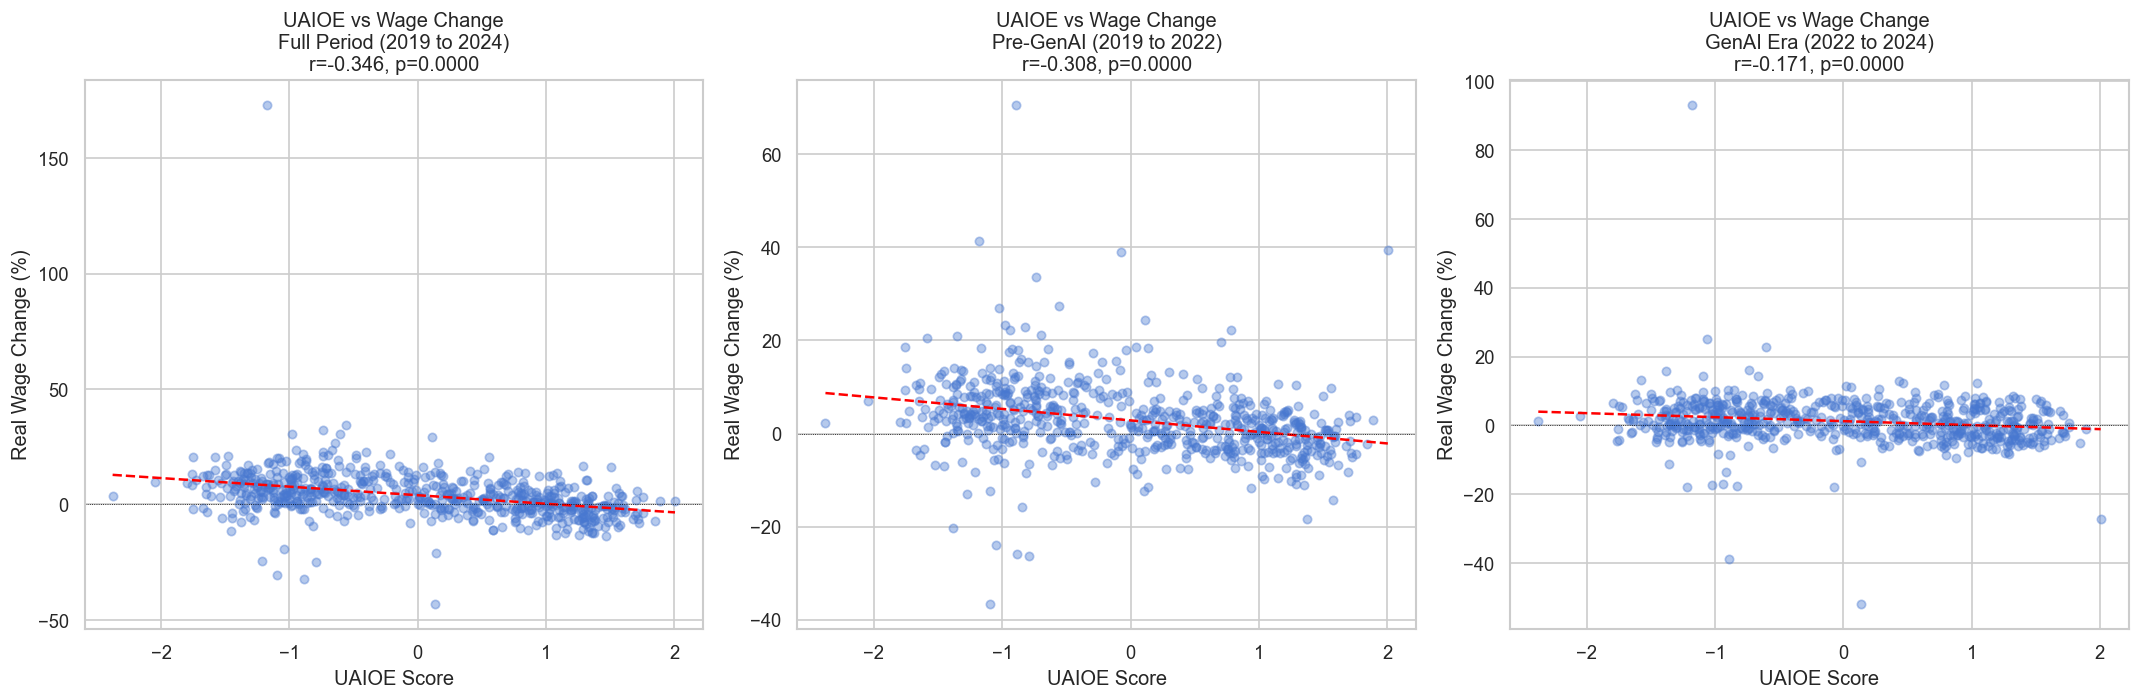

In [61]:
fig, axes = plt.subplots(1, 3, figsize=(18, 6))

periods = [
    ('wage_change_pct_19_24', 'Full Period (2019 to 2024)'),
    ('wage_change_pct_19_22', 'Pre-GenAI (2019 to 2022)'),
    ('wage_change_pct_22_24', 'GenAI Era (2022 to 2024)')
]

for ax, (col, title) in zip(axes, periods):
    plot_df = wage_data.dropna(subset=[col])
    ax.scatter(plot_df['UAIOE'], plot_df[col], alpha=0.4, s=25)
    m, b, r, p, _ = stats.linregress(plot_df['UAIOE'], plot_df[col])
    x_line = np.linspace(plot_df['UAIOE'].min(), plot_df['UAIOE'].max(), 100)
    ax.plot(x_line, m * x_line + b, color='red', linewidth=1.5, linestyle='--')
    ax.axhline(0, color='black', linewidth=0.5, linestyle=':')

    ax.set_title(f'UAIOE vs Wage Change\n{title}\nr={r:.3f}, p={p:.4f}')
    ax.set_xlabel('UAIOE Score')
    ax.set_ylabel('Real Wage Change (%)')

plt.tight_layout()
plt.show()

## 3. Pearson correlations: UAIOE and wage change

In [64]:
for col, label in periods:
    df_sub = wage_data.dropna(subset=[col])
    r, p = stats.pearsonr(df_sub['UAIOE'], df_sub[col])
    sig = '***' if p < 0.001 else ('**' if p < 0.01 else ('*' if p < 0.05 else 'ns'))
    print(f'  {label:<30} r={r:.4f}  p={p:.4f}  {sig}')

  Full Period (2019 to 2024)     r=-0.3464  p=0.0000  ***
  Pre-GenAI (2019 to 2022)       r=-0.3079  p=0.0000  ***
  GenAI Era (2022 to 2024)       r=-0.1711  p=0.0000  ***


# 4 Random Forest Benchmarking

## 4.1 Random Forest Regression: Wage Change (2019 to 2024)

In [69]:
exclude = [
    'OCC_CODE', 'OCC_TITLE', 'occ_major_group',
    'AIOE', 'AIOE_z', 'UAIOE', 'UAIOE_ev',
    'AIOE_rank', 'UAIOE_rank', 'rank_diff', 'abs_rank_diff',
    'cluster', 'cluster_label',
    'TOT_EMP_2019', 'TOT_EMP_2022', 'TOT_EMP_2024',
    'real_median_wage_2019', 'real_median_wage_2022', 'real_median_wage_2024',
    'emp_change_pct_19_24', 'emp_change_pct_19_22', 'emp_change_pct_22_24',
    'wage_change_pct_19_24', 'wage_change_pct_19_22', 'wage_change_pct_22_24'
]

feature_cols = [
    c for c in data.columns
    if c not in exclude and not c.startswith('A_PCT')
]

In [67]:
rf_data = wage_data.dropna(subset=['wage_change_pct_19_24'])
X_rf = rf_data[feature_cols]
y_rf = rf_data['wage_change_pct_19_24']

In [78]:
# Train/test split 80/20
X_train, X_test, y_train, y_test = train_test_split(
    X_rf, y_rf, test_size=0.2, random_state=42
)

print(f'Training samples: {len(X_train)}')
print(f'Test samples:     {len(X_test)}')

Training samples: 524
Test samples:     131


In [80]:
rf_wage = RandomForestRegressor(
    n_estimators=200, random_state=42, n_jobs=-1
)
rf_wage.fit(X_train, y_train)

# Test set performance
y_pred = rf_wage.predict(X_test)
r2_wage = r2_score(y_test, y_pred)
rmse_wage = np.sqrt(mean_squared_error(y_test, y_pred))

In [82]:
print(f'\nRandom Forest — Wage Change 2019→2024')

# 5-fold cross-validation
cv_scores_w = cross_val_score(
    rf_wage, X_rf, y_rf, cv=5, scoring='r2'
)


print(f'  CV R² (5-fold): {cv_scores_w.mean():.4f} ± {cv_scores_w.std():.4f}')


Random Forest — Wage Change 2019→2024
  R² (test set):  0.3240
  RMSE:           7.3798
  CV R² (5-fold): -0.1107 ± 0.1938


## 4.1 Feature Importance: Best O*NET Features to Predict Wage Change

In [83]:
importances_w = pd.Series(
    rf_wage.feature_importances_,
    index=feature_cols
).sort_values(ascending=False)

### 4.1.1 Top 20 O*NET features predicting wage change (2019 to 2024)

In [85]:
print(importances_w.head(20).round(4).to_string())

written_expression                                                                 0.0845
information_ordering                                                               0.0446
estimating_the_quantifiable_characteristics_of_products,_events,_or_information    0.0354
evaluating_information_to_determine_compliance_with_standards                      0.0319
analyzing_data_or_information                                                      0.0314
making_decisions_and_solving_problems                                              0.0295
perceptual_speed                                                                   0.0278
training_and_teaching_others                                                       0.0261
identifying_objects,_actions,_and_events                                           0.0247
problem_sensitivity                                                                0.0245
drafting,_laying_out,_and_specifying_technical_devices,_parts,_and_equipment       0.0240
speed_of_c

### 4.1.2nBottom 10 least important features

In [86]:
print(importances_w.tail(10).round(4).to_string())

originality                0.0025
selective_attention        0.0025
speech_clarity             0.0024
multilimb_coordination     0.0023
dynamic_strength           0.0019
oral_comprehension         0.0018
oral_expression            0.0017
dynamic_flexibility        0.0016
speech_recognition         0.0013
gross_body_coordination    0.0013


### 4.1.3 Top 15 Feature Importances

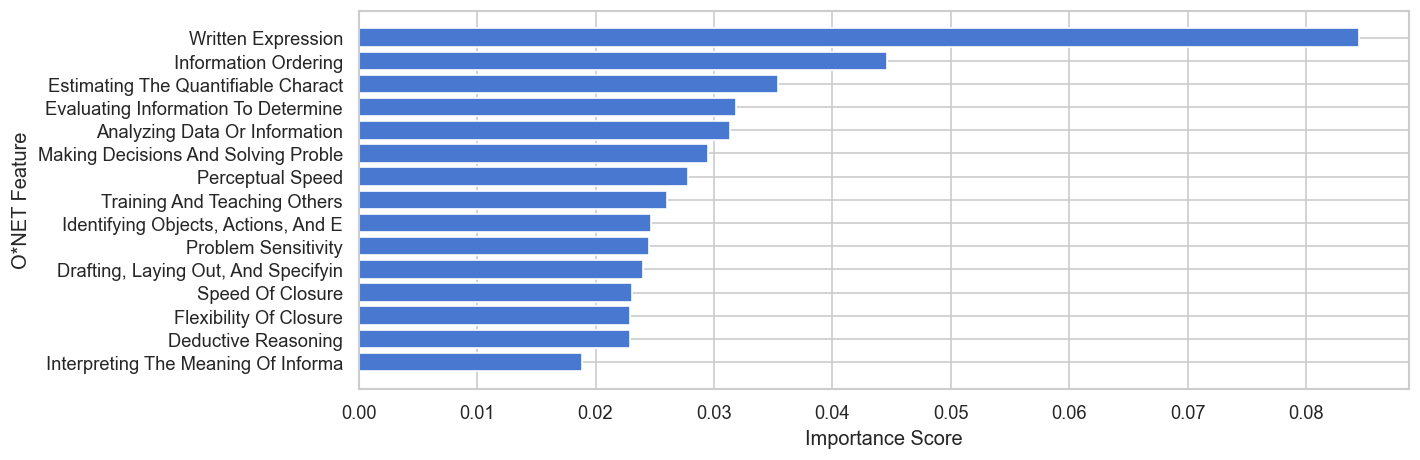

In [96]:
top15_w = importances_w.head(15)

fig, ax = plt.subplots(figsize=(12, 4))
ax.barh(
    [c.replace('_', ' ').title()[:35] for c in top15_w.index[::-1]],
    top15_w.values[::-1],
)
ax.set_xlabel('Importance Score')
ax.set_ylabel('O*NET Feature')
plt.tight_layout()
plt.show()

### 4.1.4 Importance Ranking of AI-Relevant Cognitive Ability Features

In [98]:
cognitive = [
    'oral_comprehension', 'written_comprehension', 'deductive_reasoning',
    'inductive_reasoning', 'information_ordering', 'mathematical_reasoning',
    'oral_expression', 'written_expression', 'fluency_of_ideas'
]

for feat in cognitive:
    if feat in importances_w.index:
        rank = importances_w.index.get_loc(feat) + 1
        print(f'  {feat:<35} importance={importances_w[feat]:.4f}  rank={rank}')

  oral_comprehension                  importance=0.0018  rank=89
  written_comprehension               importance=0.0080  rank=38
  deductive_reasoning                 importance=0.0229  rank=14
  inductive_reasoning                 importance=0.0148  rank=23
  information_ordering                importance=0.0446  rank=2
  mathematical_reasoning              importance=0.0089  rank=34
  oral_expression                     importance=0.0017  rank=90
  written_expression                  importance=0.0845  rank=1
  fluency_of_ideas                    importance=0.0122  rank=27


# 5 Packaging

In [106]:
wage_results = {
    'ols_full_coef':    model_wage_full.params["UAIOE"],
    'ols_full_r2':      model_wage_full.rsquared,
    'ols_full_adj_r2':  model_wage_full.rsquared_adj,
    'ols_full_p':       model_wage_full.pvalues["UAIOE"],
    'ols_full_n':       int(model_wage_full.nobs),
    'ols_1922_coef':    model_wage_1922.params["UAIOE"],
    'ols_1922_r2':      model_wage_1922.rsquared,
    'ols_1922_p':       model_wage_1922.pvalues["UAIOE"],
    'ols_2224_coef':    model_wage_2224.params["UAIOE"],
    'ols_2224_r2':      model_wage_2224.rsquared,
    'ols_2224_p':       model_wage_2224.pvalues["UAIOE"],
    'rf_r2_test':       r2_wage,
    'rf_rmse':          rmse_wage,
    'rf_cv_r2_mean':    cv_scores_w.mean(),
    'rf_cv_r2_std':     cv_scores_w.std()
}

print(json.dumps(
    {k: round(float(v), 4) for k, v in wage_results.items()},
    indent=2
))

{
  "ols_full_coef": -3.7094,
  "ols_full_r2": 0.12,
  "ols_full_adj_r2": 0.1187,
  "ols_full_p": 0.0,
  "ols_full_n": 655.0,
  "ols_1922_coef": -2.473,
  "ols_1922_r2": 0.0948,
  "ols_1922_p": 0.0,
  "ols_2224_coef": -1.1594,
  "ols_2224_r2": 0.0293,
  "ols_2224_p": 0.0,
  "rf_r2_test": 0.324,
  "rf_rmse": 7.3798,
  "rf_cv_r2_mean": -0.1107,
  "rf_cv_r2_std": 0.1938
}


In [107]:
importances_w.reset_index().rename(
    columns={'index': 'feature', 0: 'importance'}
).to_csv(
    '../data/processed/rf_wage_feature_importance.csv',
    index=False
)
print('Saved: rf_wage_feature_importance.csv')

Saved: rf_wage_feature_importance.csv
